## Learning Curve — MIL Gated Attention
### Stratégie : jeux équilibrés croissants (10R+10S → 15R+15S → ... → 53R+53S)
Objectif : montrer qu'on obtient un modèle performant avec un **minimum de données**.

In [1]:
import torch, gc
gc.collect()
torch.cuda.empty_cache()

import sys
print(f"Python : {sys.version}")
print(f"Torch  : {torch.__version__}")
print(f"CUDA   : {torch.cuda.is_available()}")
#if torch.cuda.is_available():
    #print(f"GPU    : {torch.cuda.get_device_name()}")

Python : 3.14.3 | packaged by conda-forge | (main, Feb  9 2026, 21:56:02) [GCC 14.3.0]
Torch  : 2.11.0+cu130
CUDA   : True


In [2]:
import os, glob, random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                              precision_recall_curve)
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

In [3]:
# Configuration de hyperparamètres

PT_DIR      = "embeddings_out"
LABELS_PATH = "matrice_listantibio_final.cleaned.list"

SEED       = 42
BATCH_SIZE = 4
EPOCHS     = 80
LR         = 3e-4
ATTN_DIM   = 128
HIDDEN     = 128
DROPOUT    = 0.3

# Paliers : nombre de génomes PAR CLASSE (S et R)
SIZES     = [10, 15, 20, 25, 30, 35, 40, 45, 50, 53]
N_REPEATS = 5   # répétitions par palier pour stabiliser les résultats

device = "cuda" if torch.cuda.is_available() else "cpu"

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)
print(f" Config | device : {device}")
print(f"   Paliers (par classe) : {SIZES}")
print(f"   Soit en total génomes : {[2*s for s in SIZES]}")
print(f"   Répétitions par palier : {N_REPEATS}")

 Config | device : cuda
   Paliers (par classe) : [10, 15, 20, 25, 30, 35, 40, 45, 50, 53]
   Soit en total génomes : [20, 30, 40, 50, 60, 70, 80, 90, 100, 106]
   Répétitions par palier : 5


In [4]:
# Chargement des embeddings et labels

def load_pt(fp):
    obj = torch.load(fp, map_location="cpu")
    gid = str(obj.get("genome_id", os.path.splitext(os.path.basename(fp))[0]))
    X   = obj["last_hidden_state"]
    if isinstance(X, np.ndarray):
        X = torch.from_numpy(X)
    if X.ndim == 3:
        X = X.squeeze(0)
    return gid, X.float()

def load_labels(path):
    df = pd.read_csv(path, sep=None, engine="python")
    df["#Genome_ID_Genome_name"] = df["#Genome_ID_Genome_name"].astype(str)
    return dict(zip(df["#Genome_ID_Genome_name"], df["Resistant"].astype(int)))

id_to_y = load_labels(LABELS_PATH)

all_files = sorted(glob.glob(os.path.join(PT_DIR, "*.pt")))
matched   = [fp for fp in all_files if load_pt(fp)[0] in id_to_y]

all_labels      = np.array([id_to_y[load_pt(fp)[0]] for fp in matched])
resistant_idx   = np.where(all_labels == 1)[0]   # indices dans matched[]
susceptible_idx = np.where(all_labels == 0)[0]

n_R = len(resistant_idx)
n_S = len(susceptible_idx)

_, X0   = load_pt(matched[0])
emb_dim = X0.shape[1]

print(f" Dataset complet :")
print(f"   Total labellisés : {len(matched)}")
print(f"   Résistants  (R)  : {n_R}  ({n_R/len(matched):.1%})")
print(f"   Sensibles   (S)  : {n_S}  ({n_S/len(matched):.1%})")
print(f"   Embedding dim    : {emb_dim}")
print(f"   Palier max       : {min(n_R, n_S)} par classe")

 Dataset complet :
   Total labellisés : 907
   Résistants  (R)  : 53  (5.8%)
   Sensibles   (S)  : 854  (94.2%)
   Embedding dim    : 480
   Palier max       : 53 par classe


In [5]:
# Définition de Dataset MIL & collate

class GenomeMILDataset(Dataset):
    def __init__(self, file_list, id_to_y):
        self.files   = file_list
        self.id_to_y = id_to_y

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        gid, X = load_pt(self.files[idx])
        y = float(self.id_to_y[gid])
        return X, torch.tensor(y, dtype=torch.float32), gid


def mil_collate(batch):
    xs, ys, gids = zip(*batch)
    D    = xs[0].shape[1]
    Pmax = max(x.shape[0] for x in xs)
    Xpad = torch.zeros((len(xs), Pmax, D))
    mask = torch.zeros((len(xs), Pmax))
    for i, x in enumerate(xs):
        Xpad[i, :x.shape[0]] = x
        mask[i, :x.shape[0]] = 1.0
    return Xpad, mask, torch.stack(list(ys)), list(gids)

In [12]:
# Modèle MIL Gated Attention

class FocalLoss(nn.Module):
    def __init__(self, alpha=0.5, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        bce  = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        pt   = torch.exp(-bce)
        return (self.alpha * (1 - pt) ** self.gamma * bce).mean()

class GatedAttentionMIL(nn.Module):
    def __init__(self, emb_dim, attn_dim=128, hidden=128, dropout=0.2):
        super().__init__()
        self.drop = nn.Dropout(dropout)
        self.V = nn.Sequential(nn.Linear(emb_dim, attn_dim), nn.Tanh())
        self.U = nn.Sequential(nn.Linear(emb_dim, attn_dim), nn.Sigmoid())
        self.w = nn.Linear(attn_dim, 1)
        self.classifier = nn.Sequential(
            nn.Linear(emb_dim, hidden),
            nn.BatchNorm1d(hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 1),
        )

    def forward(self, X, mask):
        X = self.drop(X)
        A = self.w(self.V(X) * self.U(X)).squeeze(-1)
        A = A.masked_fill(mask == 0, float("-inf"))
        alpha = torch.softmax(A, dim=1)
        z     = torch.sum(X * alpha.unsqueeze(-1), dim=1)
        logit = self.classifier(z).squeeze(-1)
        return logit, alpha


@torch.no_grad()
def get_probs(model, loader):
    model.eval()
    all_y, all_prob = [], []
    for Xpad, mask, y, _ in loader:
        logits, _ = model(Xpad.to(device), mask.to(device))
        all_prob.append(torch.sigmoid(logits).cpu().numpy())
        all_y.append(y.numpy())
    return np.concatenate(all_y), np.concatenate(all_prob)

def find_best_threshold(y_true, y_prob):
    p, r, thr = precision_recall_curve(y_true, y_prob)
    f1s = 2*p*r / (p+r+1e-8)
    return float(thr[np.argmax(f1s)])

def compute_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    auc = roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else None
    return {
        "acc": accuracy_score(y_true, y_pred),
        "f1":  f1_score(y_true, y_pred, zero_division=0),
        "auc": auc,
    }

n_params = sum(p.numel() for p in
               GatedAttentionMIL(emb_dim, ATTN_DIM, HIDDEN, DROPOUT).parameters()
               if p.requires_grad)
print(f" Modèle prêt | emb_dim={emb_dim} | paramètres={n_params:,}")

 Modèle prêt | emb_dim=480 | paramètres=185,218


In [23]:
set_seed(SEED)
N_TEST_EXT = 15

lc_results  = []
best_models = {}

print(f"{'Palier train':>14} | {'Test':>20} | {'AUC moy':>8} {'±':>5} | {'F1opt moy':>9} {'±':>5}")
print("-" * 72)

for n_per_class in SIZES:

    size_aucs, size_f1opts = [], []
    best_auc_this_palier   = -1.0
    best_state_this_palier = None

    use_external = (len(resistant_idx) - n_per_class >= N_TEST_EXT)
    test_mode    = f"{N_TEST_EXT}R+{N_TEST_EXT}S ext." \
                   if use_external else "80/20 int."

    for rep in range(N_REPEATS):

        seed_run = SEED + rep * 100 + n_per_class
        set_seed(seed_run)

        if use_external:
            # Train : n_per_class R tirés parmi TOUS les résistants
            sel_R = np.random.choice(resistant_idx,   size=n_per_class, replace=False)
            sel_S = np.random.choice(susceptible_idx, size=n_per_class, replace=False)
            tr_files  = [matched[i] for i in np.concatenate([sel_R, sel_S])]
            tr_labels = np.array([id_to_y[load_pt(f)[0]] for f in tr_files])

            # Test : 15R tirés parmi les R restants
            remaining_R = np.setdiff1d(resistant_idx, sel_R)   # 53 - n_per_class
            remaining_S = np.setdiff1d(susceptible_idx, sel_S)
            te_R = np.random.choice(remaining_R, size=N_TEST_EXT, replace=False)
            te_S = np.random.choice(remaining_S, size=N_TEST_EXT, replace=False)
            te_files = [matched[i] for i in np.concatenate([te_R, te_S])]

        else:
            # 80/20 interne quand pas assez de R restants
            sel_R = np.random.choice(resistant_idx,   size=n_per_class, replace=False)
            sel_S = np.random.choice(susceptible_idx, size=n_per_class, replace=False)
            sel_files  = [matched[i] for i in np.concatenate([sel_R, sel_S])]
            sel_labels = np.array([id_to_y[load_pt(f)[0]] for f in sel_files])

            tr_idx, te_idx = train_test_split(
                np.arange(len(sel_files)),
                test_size=0.20,
                stratify=sel_labels,
                random_state=seed_run
            )
            tr_files  = [sel_files[i] for i in tr_idx]
            te_files  = [sel_files[i] for i in te_idx]
            tr_labels = sel_labels[tr_idx]

        # DataLoaders 
        tr_ds = GenomeMILDataset(tr_files, id_to_y)
        te_ds = GenomeMILDataset(te_files, id_to_y)

        bs = max(2, min(BATCH_SIZE, n_per_class // 2))

        tr_loader = DataLoader(tr_ds, batch_size=bs, shuffle=True, collate_fn=mil_collate)
        te_loader = DataLoader(te_ds, batch_size=bs, shuffle=False,   collate_fn=mil_collate)

        # Entraînement
        model     = GatedAttentionMIL(emb_dim, ATTN_DIM, HIDDEN, DROPOUT).to(device)
        criterion = FocalLoss(alpha=0.5, gamma=2.0)
        optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-2)

        best_loss  = float("inf")
        no_improve = 0
        PATIENCE   = 10

        for epoch in range(1, EPOCHS + 1):
            model.train()
            epoch_loss, n_batches = 0.0, 0
            for Xpad, mask, y, _ in tr_loader:
                Xpad, mask, y = Xpad.to(device), mask.to(device), y.to(device)
                optimizer.zero_grad()
                logits, _ = model(Xpad, mask)
                loss = criterion(logits, y)
                loss.backward()
                optimizer.step()
                epoch_loss += loss.item()
                n_batches  += 1

            train_loss = epoch_loss / n_batches
            if train_loss < best_loss - 1e-4:
                best_loss  = train_loss
                no_improve = 0
            else:
                no_improve += 1
                if no_improve >= PATIENCE:
                    break

        # Évaluation
        test_y, test_prob = get_probs(model, te_loader)
        m = compute_metrics(test_y, test_prob, threshold=0.5)

        auc_rep = m["auc"] or 0.0
        size_aucs.append(auc_rep)
        size_f1opts.append(m["f1"])

        if auc_rep > best_auc_this_palier:
            best_auc_this_palier   = auc_rep
            best_state_this_palier = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }

    best_models[n_per_class] = best_state_this_palier
    best_rep = int(np.argmax(size_aucs))

    lc_results.append({
        "n_per_class": n_per_class,
        "n_total":     2 * n_per_class,
        "test_mode":   test_mode,
        "best_rep":    best_rep,
        "auc_mean":    np.mean(size_aucs),
        "auc_std":     np.std(size_aucs),
        "f1opt_mean":  np.mean(size_f1opts),
        "f1opt_std":   np.std(size_f1opts),
        "all_aucs":    size_aucs,
        "all_f1opts":  size_f1opts,
    })

    print(
        f"  {n_per_class:3d}R+{n_per_class:3d}S = {2*n_per_class:3d} | "
        f"{test_mode:>20} | "
        f"{np.mean(size_aucs):8.3f} {np.std(size_aucs):5.3f} | "
        f"{np.mean(size_f1opts):9.3f} {np.std(size_f1opts):5.3f} | "
        f"best_rep={best_rep}"
    )

print("\n Learning Curve terminée !")
print(f"   Modèles en mémoire : best_models[n] pour n dans {list(best_models.keys())}")

  Palier train |                 Test |  AUC moy     ± | F1opt moy     ±
------------------------------------------------------------------------
   10R+ 10S =  20 |         15R+15S ext. |    0.832 0.075 |     0.722 0.112 | best_rep=3
   15R+ 15S =  30 |         15R+15S ext. |    0.844 0.084 |     0.754 0.084 | best_rep=3
   20R+ 20S =  40 |         15R+15S ext. |    0.887 0.059 |     0.750 0.063 | best_rep=4
   25R+ 25S =  50 |         15R+15S ext. |    0.850 0.026 |     0.804 0.034 | best_rep=4
   30R+ 30S =  60 |         15R+15S ext. |    0.853 0.068 |     0.529 0.347 | best_rep=3
   35R+ 35S =  70 |         15R+15S ext. |    0.842 0.060 |     0.768 0.056 | best_rep=1
   40R+ 40S =  80 |           80/20 int. |    0.850 0.078 |     0.809 0.097 | best_rep=1
   45R+ 45S =  90 |           80/20 int. |    0.953 0.040 |     0.646 0.262 | best_rep=0
   50R+ 50S = 100 |           80/20 int. |    0.908 0.065 |     0.734 0.142 | best_rep=0
   53R+ 53S = 106 |           80/20 int. |    0.907 0

In [24]:
# Résumé tableau

df_lc = pd.DataFrame([{
    "n_par_classe": r["n_per_class"],
    "n_total":      r["n_total"],
    "AUC_mean":     round(r["auc_mean"],   3),
    "AUC_std":      round(r["auc_std"],    3),
    "F1opt_mean":   round(r["f1opt_mean"], 3),
    "F1opt_std":    round(r["f1opt_std"],  3),
} for r in lc_results])

print(" Résumé Learning Curve")
print("=" * 55)
print(df_lc.to_string(index=False))
print("=" * 55)

 Résumé Learning Curve
 n_par_classe  n_total  AUC_mean  AUC_std  F1opt_mean  F1opt_std
           10       20     0.832    0.075       0.722      0.112
           15       30     0.844    0.084       0.754      0.084
           20       40     0.887    0.059       0.750      0.063
           25       50     0.850    0.026       0.804      0.034
           30       60     0.853    0.068       0.529      0.347
           35       70     0.842    0.060       0.768      0.056
           40       80     0.850    0.078       0.809      0.097
           45       90     0.953    0.040       0.646      0.262
           50      100     0.908    0.065       0.734      0.142
           53      106     0.907    0.023       0.714      0.215


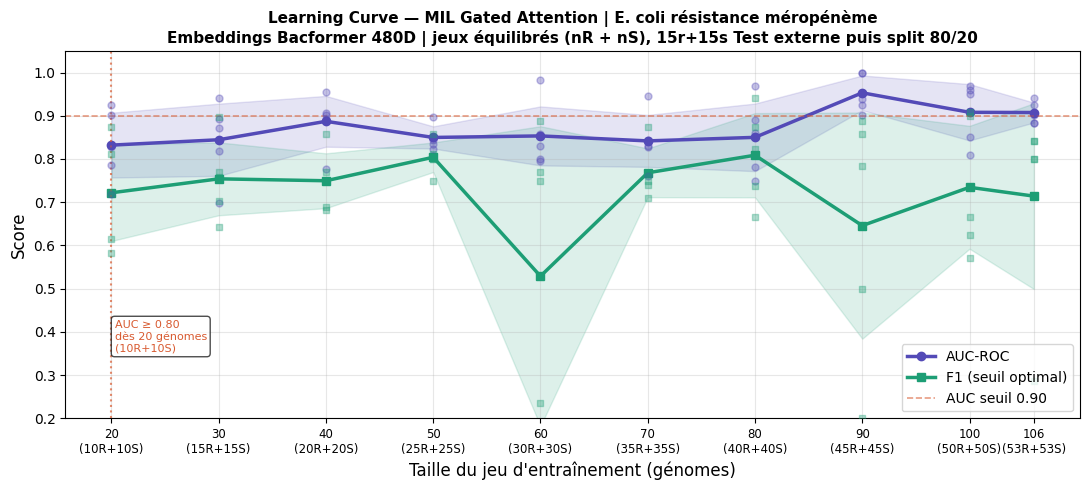

 Figure sauvegardée → learning_curve_MIL.png


In [35]:
# Visualisation

sizes_plot = [r["n_total"]     for r in lc_results]
auc_means  = [r["auc_mean"]    for r in lc_results]
auc_stds   = [r["auc_std"]     for r in lc_results]
f1_means   = [r["f1opt_mean"]  for r in lc_results]
f1_stds    = [r["f1opt_std"]   for r in lc_results]

COLOR_AUC = "#534AB7"
COLOR_F1  = "#1D9E75"

fig, ax = plt.subplots(figsize=(11, 5))

# AUC
ax.plot(sizes_plot, auc_means, marker="o", linewidth=2.5,
        color=COLOR_AUC, label="AUC-ROC")
ax.fill_between(sizes_plot,
                np.array(auc_means) - np.array(auc_stds),
                np.array(auc_means) + np.array(auc_stds),
                alpha=0.15, color=COLOR_AUC)

# F1
ax.plot(sizes_plot, f1_means, marker="s", linewidth=2.5,
        color=COLOR_F1, label="F1 (seuil optimal)")
ax.fill_between(sizes_plot,
                np.array(f1_means) - np.array(f1_stds),
                np.array(f1_means) + np.array(f1_stds),
                alpha=0.15, color=COLOR_F1)

# Points individuels (toutes les répétitions)
for r in lc_results:
    ax.scatter([r["n_total"]] * len(r["all_aucs"]),   r["all_aucs"],
               color=COLOR_AUC, alpha=0.35, s=25, zorder=5)
    ax.scatter([r["n_total"]] * len(r["all_f1opts"]), r["all_f1opts"],
               color=COLOR_F1,  alpha=0.35, s=25, zorder=5, marker="s")

# Ligne seuil AUC 0.9
ax.axhline(y=0.9, color="#D85A30", linestyle="--", alpha=0.6, linewidth=1.2,
           label="AUC seuil 0.90")

# Annotation premier palier AUC ≥ 0.80
first_good = next((i for i, a in enumerate(auc_means) if a >= 0.80), None)
if first_good is not None:
    s = sizes_plot[first_good]
    ax.axvline(x=s, color="#D85A30", linestyle=":", alpha=0.7, linewidth=1.5)
    ax.text(s + 0.3, 0.35,
            f"AUC ≥ 0.80\ndès {s} génomes\n({s//2}R+{s//2}S)",
            fontsize=8, color="#D85A30", va="bottom",
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7))

ax.set_xlabel("Taille du jeu d'entraînement (génomes)", fontsize=12)
ax.set_ylabel("Score", fontsize=12)
ax.set_title(
    "Learning Curve — MIL Gated Attention | E. coli résistance méropénème\n"
    "Embeddings Bacformer 480D | jeux équilibrés (nR + nS), 15r+15s Test externe puis split 80/20",
    fontsize=11, fontweight="bold"
)
ax.set_ylim(0.2, 1.05)
ax.set_xticks(sizes_plot)
ax.set_xticklabels([f"{s}\n({s//2}R+{s//2}S)" for s in sizes_plot], fontsize=8.5)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("learning_curve_MIL.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Figure sauvegardée → learning_curve_MIL.png")

In [28]:
print("=" * 60)
print("                      INTERPRÉTATION")
print("=" * 60)

best_auc_i = int(np.argmax(auc_means))
best_f1_i  = int(np.argmax(f1_means))
first_80   = next((i for i, a in enumerate(auc_means) if a >= 0.80), None)
first_90   = next((i for i, a in enumerate(auc_means) if a >= 0.90), None)

print(f"\n  Meilleure AUC : {auc_means[best_auc_i]:.3f} ± {auc_stds[best_auc_i]:.3f}")
print(f"    → {sizes_plot[best_auc_i]} génomes ({sizes_plot[best_auc_i]//2}R + {sizes_plot[best_auc_i]//2}S)")

print(f"\n  Meilleur F1   : {f1_means[best_f1_i]:.3f} ± {f1_stds[best_f1_i]:.3f}")
print(f"    → {sizes_plot[best_f1_i]} génomes ({sizes_plot[best_f1_i]//2}R + {sizes_plot[best_f1_i]//2}S)")

if first_80 is not None:
    s = sizes_plot[first_80]
    print(f"\n   AUC ≥ 0.80 atteinte dès {s} génomes ({s//2}R+{s//2}S)")

if first_90 is not None:
    s = sizes_plot[first_90]
    print(f"   AUC ≥ 0.90 atteinte dès {s} génomes ({s//2}R+{s//2}S)")

if first_80 is None:
    print("    AUC < 0.80 sur tous les paliers")

print("\n" + "=" * 60)

                      INTERPRÉTATION

  Meilleure AUC : 0.953 ± 0.040
    → 90 génomes (45R + 45S)

  Meilleur F1   : 0.809 ± 0.097
    → 80 génomes (40R + 40S)

   AUC ≥ 0.80 atteinte dès 20 génomes (10R+10S)
   AUC ≥ 0.90 atteinte dès 90 génomes (45R+45S)



In [29]:
# Fonction load_labels + load_pt
PT_DIR   = "embeddings_out"
GBK_DIR  = "genomes_gbff"
RGI_DIR  = "rgi_results"
LABELS_PATH = "matrice_listantibio_final.cleaned.list"
 
def load_labels(path):
    df = pd.read_csv(path, sep=None, engine="python")
    df["#Genome_ID_Genome_name"] = df["#Genome_ID_Genome_name"].astype(str)
    df["Resistant"]   = df["Resistant"].astype(int)
    df["Susceptible"] = df["Susceptible"].astype(int)
    return dict(zip(df["#Genome_ID_Genome_name"], df["Resistant"]))
 
def load_pt(fp):
    obj = torch.load(fp)
    gid = str(obj.get("genome_id", os.path.splitext(os.path.basename(fp))[0]))
    X   = obj["last_hidden_state"]
    if isinstance(X, np.ndarray):
        X = torch.from_numpy(X)
    if X.ndim == 3:
        X = X.squeeze(0)
    if X.ndim != 2:
        raise ValueError(f"{fp}: shape inattendue {tuple(X.shape)}")
    return gid, X.float()
 
# Charge labels + fichiers
id_to_y   = load_labels(LABELS_PATH)
all_files = sorted(glob.glob(os.path.join(PT_DIR, "*.pt")))
matched   = [fp for fp in all_files if load_pt(fp)[0] in id_to_y]
resistant_files  = [fp for fp in matched if id_to_y[load_pt(fp)[0]] == 1]
susceptible_files= [fp for fp in matched if id_to_y[load_pt(fp)[0]] == 0]
 
print(f"Labels chargés")
print(f"Total .pt matchés  : {len(matched)}")
print(f"Résistants         : {len(resistant_files)}")
print(f"Sensibles          : {len(susceptible_files)}")

Labels chargés
Total .pt matchés  : 907
Résistants         : 53
Sensibles          : 854


In [30]:
# IDs dans tes .pt
pt_ids  = set(os.path.splitext(os.path.basename(f))[0]
              for f in glob.glob("embeddings_out/*.pt"))

# IDs dans tes résultats RGI
rgi_ids = set(os.path.splitext(os.path.basename(f))[0]
              for f in glob.glob("rgi_results/*.txt"))

# IDs dans tes .gbff
gbff_ids = set(os.path.splitext(os.path.basename(f))[0]
               for f in glob.glob("genomes_gbff/*.gbff"))

print(f"IDs dans .pt   : {len(pt_ids)}")
print(f"IDs dans RGI   : {len(rgi_ids)}")
print(f"IDs dans .gbff : {len(gbff_ids)}")

IDs dans .pt   : 1066
IDs dans RGI   : 1066
IDs dans .gbff : 1066


In [31]:
# Parser le .gbff pour extraire les CDS dans l'ordre
from Bio import SeqIO

def load_gbff_annotation(genome_id):
    gbff_file = os.path.join(GBK_DIR, f"{genome_id}.gbff")
    if not os.path.exists(gbff_file):
        print(f"Fichier non trouvé : {gbff_file}")
        return None
    rows = []
    for record in SeqIO.parse(gbff_file, "genbank"):
        for feature in record.features:
            if feature.type != "CDS":
                continue
            rows.append({
                "contig":    record.id,
                "start":     int(feature.location.start),
                "end":       int(feature.location.end),
                "strand":    int(feature.location.strand),
                "locus_tag": feature.qualifiers.get("locus_tag", [""])[0],
                "gene":      feature.qualifiers.get("gene",      [""])[0],
                "product":   feature.qualifiers.get("product",   ["unknown"])[0],
            })
    if not rows:
        print(f"Aucun CDS trouvé")
        return None
    df = pd.DataFrame(rows).reset_index()
    return df.rename(columns={"index": "protein_index"})
 
# Test sur le premier génome disponible
sample_gid = load_pt(all_files[0])[0]
ann_test   = load_gbff_annotation(sample_gid)
 
if ann_test is not None:
    print(f".gbff chargé pour : {sample_gid}")
    print(f"   Nb CDS : {len(ann_test)}")
    print(ann_test[["protein_index","gene","product","start","end"]].head(10))
else:
    print("Problème — vérifie GBK_DIR et le nom des fichiers")

.gbff chargé pour : 1328432.3
   Nb CDS : 4665
   protein_index    gene                                            product  \
0              0    thrA  Bifunctional aspartokinase/homoserine dehydrog...   
1              1    thrB                                  Homoserine kinase   
2              2    thrC                                 Threonine synthase   
3              3                                       hypothetical protein   
4              4    yaaA  DNA-binding and peroxide stress resistance pro...   
5              5    alsT                    Amino-acid carrier protein AlsT   
6              6  talB_1                                    Transaldolase B   
7              7     mog                  Molybdopterin adenylyltransferase   
8              8    satP            Succinate-acetate/proton symporter SatP   
9              9                                       hypothetical protein   

   start    end  
0    335   2798  
1   2799   3732  
2   3732   5019  
3   5232   

In [32]:
# Parser les résultats RGI
 
def load_rgi_meropenem(genome_id):
    rgi_file = os.path.join(RGI_DIR, f"{genome_id}.txt")
    if not os.path.exists(rgi_file):
        return None

    df = pd.read_csv(rgi_file, sep="\t")

    # Garde Perfect + Strict uniquement
    df = df[df["Cut_Off"].isin(["Perfect", "Strict"])].copy()
    if len(df) == 0:
        return None

    # ── Filtre méropénème sur "Drug Class" ───
    mask = df["Drug Class"].str.lower().str.contains(
        "carbapenem|penem", na=False
    )
    df = df[mask].copy()
    if len(df) == 0:
        return None

    # Parse start/stop depuis Start/Stop
    df["rgi_start"] = df["Start"].astype(int)
    df["rgi_stop"]  = df["Stop"].astype(int)

    return df.reset_index(drop=True)

# Test sur le premier génome résistant
test_gid = load_pt(resistant_files[0])[0]
rgi_test = load_rgi_meropenem(test_gid)

print(f"Test RGI méropénème sur : {test_gid}")
if rgi_test is not None:
    print(f"   Nb gènes carbapénème détectés : {len(rgi_test)}")
    print(rgi_test[["Best_Hit_ARO", "Drug Class", "Cut_Off", "Best_Identities"]].to_string(index=False))
else:
    print("Aucun gène carbapénème trouvé")
    # Diagnostic — affiche tous les Drug Class trouvés
    df_all = pd.read_csv(os.path.join(RGI_DIR, f"{test_gid}.txt"), sep="\t")
    df_all = df_all[df_all["Cut_Off"].isin(["Perfect","Strict"])]
    print(f"\n   Tous les Drug Class trouvés :")
    for dc in df_all["Drug Class"].unique():
        print(f"     → {dc}")

Test RGI méropénème sur : 1328437.3
   Nb gènes carbapénème détectés : 3
                                                        Best_Hit_ARO                                                                                                                                                                                                        Drug Class Cut_Off  Best_Identities
                                                                marA fluoroquinolone antibiotic; monobactam; carbapenem; cephalosporin; glycylcycline; penicillin beta-lactam; tetracycline antibiotic; rifamycin antibiotic; phenicol antibiotic; disinfecting agents and antiseptics Perfect            100.0
                                                               KPC-2                                                                                                                                                     monobactam; carbapenem; cephalosporin; penicillin beta-lactam Perfect            100.0
Escherichia col

In [33]:
# Choix du palier → top protéines annotées

N_BEST = 20   # ← change ici : 10, 15, 20, 25, 30, 35, 40, 45, 50, 53

# Vérification 
assert N_BEST in best_models, \
    f" Palier {N_BEST} non disponible. Paliers dispo : {list(best_models.keys())}"

model_best = GatedAttentionMIL(emb_dim, ATTN_DIM, HIDDEN, DROPOUT).to(device)
model_best.load_state_dict(best_models[N_BEST])
model_best.eval()

r_info = next(x for x in lc_results if x["n_per_class"] == N_BEST)
print(f" Modèle chargé depuis mémoire : palier {N_BEST}R+{N_BEST}S = {2*N_BEST} génomes")
print(f"   AUC  : {r_info['auc_mean']:.3f} ± {r_info['auc_std']:.3f}")
print(f"   F1   : {r_info['f1opt_mean']:.3f} ± {r_info['f1opt_std']:.3f}")
print(f"   Test : {r_info['test_mode']}\n")

# Full eval loader 
full_dataset     = GenomeMILDataset(matched, id_to_y)
full_eval_loader = DataLoader(full_dataset, batch_size=BATCH_SIZE,
                              shuffle=False, collate_fn=mil_collate)

def get_top_attention_with_annotation(model, loader, gbk_dir=GBK_DIR, top_k=10):
    model.eval()
    results = []
    with torch.no_grad():
        for Xpad, mask, y, gids in loader:
            Xpad, mask    = Xpad.to(device), mask.to(device)
            logits, alpha = model(Xpad, mask)
            probs         = torch.sigmoid(logits).cpu().numpy()

            for i, gid in enumerate(gids):
                n_prot  = int(mask[i].sum().item())
                attn    = alpha[i, :n_prot].cpu().numpy()
                top_idx = np.argsort(attn)[::-1][:top_k]

                entropy     = float(-np.sum(attn * np.log(attn + 1e-12)))
                max_entropy = float(np.log(n_prot))

                ann = load_gbff_annotation(gid)
                top_proteins = []
                for rank, idx in enumerate(top_idx, 1):
                    entry = {
                        "rank":             rank,
                        "protein_index":    int(idx),
                        "attention_weight": float(attn[idx]),
                        "attention_pct":    float(100 * attn[idx] / attn.sum()),
                    }
                    if ann is not None and idx < len(ann):
                        row = ann.iloc[idx]
                        entry["gene"]      = row.get("gene",      None) or "—"
                        entry["product"]   = row.get("product",   None) or "—"
                        entry["locus_tag"] = row.get("locus_tag", None) or "—"
                    else:
                        entry["gene"]      = "?"
                        entry["product"]   = "?"
                        entry["locus_tag"] = "?"
                    top_proteins.append(entry)

                results.append({
                    "genome_id":        gid,
                    "true_label":       int(y[i].item()),
                    "predicted_prob":   float(probs[i]),
                    "predicted_label":  int(probs[i] >= 0.5),
                    "correct":          int(y[i].item()) == int(probs[i] >= 0.5),
                    "n_proteins":       n_prot,
                    "attn_entropy_pct": float(entropy / max_entropy) if max_entropy > 0 else 1.0,
                    "top_proteins":     top_proteins,
                })
    return results

top_attn_ann  = get_top_attention_with_annotation(model_best, full_eval_loader, top_k=10)
resistant_ann = [r for r in top_attn_ann if r["true_label"] == 1]
correct_R     = sum(1 for r in resistant_ann if r["correct"])

# Affichage 
print(f"Palier {N_BEST}R+{N_BEST}S — génomes RÉSISTANTS ({len(resistant_ann)})")
print(f"Prédictions correctes : {correct_R}/{len(resistant_ann)} "
      f"({correct_R/len(resistant_ann):.1%})\n")

for r in resistant_ann:
    icon = "CORRECT" if r["correct"] else "NOT CORRECT"
    print(f"\n{'='*85}")
    print(f"{icon}  Genome : {r['genome_id']}  |  "
          f"P(resistant)={r['predicted_prob']:.3f}  |  "
          f"{r['n_proteins']} protéines  |  "
          f"Entropie : {r['attn_entropy_pct']:.1%}")
    print(f"{'='*85}")
    print(f"{'Rang':>4} | {'Idx':>6} | {'Poids':>10} | {'% total':>7} | "
          f"{'Gène':>12} | Produit")
    print(f"{'-'*4}-+-{'-'*6}-+-{'-'*10}-+-{'-'*7}-+-{'-'*12}-+-{'-'*40}")
    for p in r["top_proteins"]:
        print(
            f"{p['rank']:>4} | "
            f"{p['protein_index']:>6} | "
            f"{p['attention_weight']:.8f} | "
            f"{p['attention_pct']:>6.2f}% | "
            f"{p['gene']:>12} | "
            f"{str(p['product'])[:50]}"
        )

# Export CSV
rows = []
for r in top_attn_ann:
    for p in r["top_proteins"]:
        rows.append({
            "genome_id":        r["genome_id"],
            "true_label":       r["true_label"],
            "predicted_prob":   round(r["predicted_prob"], 4),
            "correct":          r["correct"],
            "n_proteins":       r["n_proteins"],
            "attn_entropy_pct": round(r["attn_entropy_pct"], 4),
            **p
        })

df_ann = pd.DataFrame(rows)
#df_ann.to_csv(f"top_attention_{N_BEST}R_annotated.csv", index=False)
#print(f"\n Export → top_attention_{N_BEST}R_annotated.csv ({len(df_ann)} lignes)")

display(
    df_ann[df_ann["true_label"] == 1]
    .sort_values(["genome_id", "rank"])
    .reset_index(drop=True)
)

 Modèle chargé depuis mémoire : palier 20R+20S = 40 génomes
   AUC  : 0.887 ± 0.059
   F1   : 0.750 ± 0.063
   Test : 15R+15S ext.

Palier 20R+20S — génomes RÉSISTANTS (53)
Prédictions correctes : 53/53 (100.0%)


CORRECT  Genome : 1328437.3  |  P(resistant)=0.946  |  5202 protéines  |  Entropie : 99.3%
Rang |    Idx |      Poids | % total |         Gène | Produit
-----+--------+------------+---------+--------------+-----------------------------------------
   1 |   3870 | 0.00060790 |   0.06% |            — | hypothetical protein
   2 |   4082 | 0.00058155 |   0.06% |         phnN | Ribose 1,5-bisphosphate phosphokinase PhnN
   3 |   3613 | 0.00052421 |   0.05% |            — | hypothetical protein
   4 |   1155 | 0.00051688 |   0.05% |            — | hypothetical protein
   5 |   3273 | 0.00050737 |   0.05% |            — | hypothetical protein
   6 |   4499 | 0.00049944 |   0.05% |            — | hypothetical protein
   7 |   3272 | 0.00049342 |   0.05% |         rpsJ | Small riboso

,genome_id,true_label,predicted_prob,correct,n_proteins,attn_entropy_pct,rank,protein_index,attention_weight,attention_pct,gene,product,locus_tag
0,1328437.3,1,0.9460,True,5202,0.9929,1,3870,0.000608,0.060790,—,hypothetical protein,PABACNKJ_03943
1,1328437.3,1,0.9460,True,5202,0.9929,2,4082,0.000582,0.058155,phnN,"Ribose 1,5-bisphosphate phosphokinase PhnN",PABACNKJ_04160
2,1328437.3,1,0.9460,True,5202,0.9929,3,3613,0.000524,0.052421,—,hypothetical protein,PABACNKJ_03682
3,1328437.3,1,0.9460,True,5202,0.9929,4,1155,0.000517,0.051688,—,hypothetical protein,PABACNKJ_01183
4,1328437.3,1,0.9460,True,5202,0.9929,5,3273,0.000507,0.050737,—,hypothetical protein,PABACNKJ_03341
...,...,...,...,...,...,...,...,...,...,...,...,...,...
525,562.91162,1,0.9655,True,4737,0.9931,6,4157,0.000540,0.053987,rpsJ,Small ribosomal subunit protein uS10,MFDGIJDN_04257
526,562.91162,1,0.9655,True,4737,0.9931,7,4710,0.000539,0.053860,—,IS6 family transposase IS6100,MFDGIJDN_04825
527,562.91162,1,0.9655,True,4737,0.9931,8,459,0.000534,0.053358,—,hypothetical protein,MFDGIJDN_00474
528,562.91162,1,0.9655,True,4737,0.9931,9,4704,0.000522,0.052203,—,hypothetical protein,MFDGIJDN_04819


In [34]:
# Choix du palier → top protéines annotées

N_BEST = 40   # ← change ici : 10, 15, 20, 25, 30, 35, 40, 45, 50, 53

# Vérification 
assert N_BEST in best_models, \
    f" Palier {N_BEST} non disponible. Paliers dispo : {list(best_models.keys())}"

model_best = GatedAttentionMIL(emb_dim, ATTN_DIM, HIDDEN, DROPOUT).to(device)
model_best.load_state_dict(best_models[N_BEST])
model_best.eval()

r_info = next(x for x in lc_results if x["n_per_class"] == N_BEST)
print(f" Modèle chargé depuis mémoire : palier {N_BEST}R+{N_BEST}S = {2*N_BEST} génomes")
print(f"   AUC  : {r_info['auc_mean']:.3f} ± {r_info['auc_std']:.3f}")
print(f"   F1   : {r_info['f1opt_mean']:.3f} ± {r_info['f1opt_std']:.3f}")
print(f"   Test : {r_info['test_mode']}\n")

# Full eval loader
full_dataset     = GenomeMILDataset(matched, id_to_y)
full_eval_loader = DataLoader(full_dataset, batch_size=BATCH_SIZE,
                              shuffle=False, collate_fn=mil_collate)

def get_top_attention_with_annotation(model, loader, gbk_dir=GBK_DIR, top_k=10):
    model.eval()
    results = []
    with torch.no_grad():
        for Xpad, mask, y, gids in loader:
            Xpad, mask    = Xpad.to(device), mask.to(device)
            logits, alpha = model(Xpad, mask)
            probs         = torch.sigmoid(logits).cpu().numpy()

            for i, gid in enumerate(gids):
                n_prot  = int(mask[i].sum().item())
                attn    = alpha[i, :n_prot].cpu().numpy()
                top_idx = np.argsort(attn)[::-1][:top_k]

                entropy     = float(-np.sum(attn * np.log(attn + 1e-12)))
                max_entropy = float(np.log(n_prot))

                ann = load_gbff_annotation(gid)
                top_proteins = []
                for rank, idx in enumerate(top_idx, 1):
                    entry = {
                        "rank":             rank,
                        "protein_index":    int(idx),
                        "attention_weight": float(attn[idx]),
                        "attention_pct":    float(100 * attn[idx] / attn.sum()),
                    }
                    if ann is not None and idx < len(ann):
                        row = ann.iloc[idx]
                        entry["gene"]      = row.get("gene",      None) or "—"
                        entry["product"]   = row.get("product",   None) or "—"
                        entry["locus_tag"] = row.get("locus_tag", None) or "—"
                    else:
                        entry["gene"]      = "?"
                        entry["product"]   = "?"
                        entry["locus_tag"] = "?"
                    top_proteins.append(entry)

                results.append({
                    "genome_id":        gid,
                    "true_label":       int(y[i].item()),
                    "predicted_prob":   float(probs[i]),
                    "predicted_label":  int(probs[i] >= 0.5),
                    "correct":          int(y[i].item()) == int(probs[i] >= 0.5),
                    "n_proteins":       n_prot,
                    "attn_entropy_pct": float(entropy / max_entropy) if max_entropy > 0 else 1.0,
                    "top_proteins":     top_proteins,
                })
    return results

top_attn_ann  = get_top_attention_with_annotation(model_best, full_eval_loader, top_k=10)
resistant_ann = [r for r in top_attn_ann if r["true_label"] == 1]
correct_R     = sum(1 for r in resistant_ann if r["correct"])

# Affichage
print(f"Palier {N_BEST}R+{N_BEST}S — génomes RÉSISTANTS ({len(resistant_ann)})")
print(f"Prédictions correctes : {correct_R}/{len(resistant_ann)} "
      f"({correct_R/len(resistant_ann):.1%})\n")

for r in resistant_ann:
    icon = "CORRECT" if r["correct"] else "NOT CORRECT"
    print(f"\n{'='*85}")
    print(f"{icon}  Genome : {r['genome_id']}  |  "
          f"P(resistant)={r['predicted_prob']:.3f}  |  "
          f"{r['n_proteins']} protéines  |  "
          f"Entropie : {r['attn_entropy_pct']:.1%}")
    print(f"{'='*85}")
    print(f"{'Rang':>4} | {'Idx':>6} | {'Poids':>10} | {'% total':>7} | "
          f"{'Gène':>12} | Produit")
    print(f"{'-'*4}-+-{'-'*6}-+-{'-'*10}-+-{'-'*7}-+-{'-'*12}-+-{'-'*40}")
    for p in r["top_proteins"]:
        print(
            f"{p['rank']:>4} | "
            f"{p['protein_index']:>6} | "
            f"{p['attention_weight']:.8f} | "
            f"{p['attention_pct']:>6.2f}% | "
            f"{p['gene']:>12} | "
            f"{str(p['product'])[:50]}"
        )

# Export CSV
rows = []
for r in top_attn_ann:
    for p in r["top_proteins"]:
        rows.append({
            "genome_id":        r["genome_id"],
            "true_label":       r["true_label"],
            "predicted_prob":   round(r["predicted_prob"], 4),
            "correct":          r["correct"],
            "n_proteins":       r["n_proteins"],
            "attn_entropy_pct": round(r["attn_entropy_pct"], 4),
            **p
        })

df_ann = pd.DataFrame(rows)
#df_ann.to_csv(f"top_attention_{N_BEST}R_annotated.csv", index=False)
#print(f"\n Export → top_attention_{N_BEST}R_annotated.csv ({len(df_ann)} lignes)")

display(
    df_ann[df_ann["true_label"] == 1]
    .sort_values(["genome_id", "rank"])
    .reset_index(drop=True)
)

 Modèle chargé depuis mémoire : palier 40R+40S = 80 génomes
   AUC  : 0.850 ± 0.078
   F1   : 0.809 ± 0.097
   Test : 80/20 int.

Palier 40R+40S — génomes RÉSISTANTS (53)
Prédictions correctes : 50/53 (94.3%)


CORRECT  Genome : 1328437.3  |  P(resistant)=0.758  |  5202 protéines  |  Entropie : 98.5%
Rang |    Idx |      Poids | % total |         Gène | Produit
-----+--------+------------+---------+--------------+-----------------------------------------
   1 |   4216 | 0.00111856 |   0.11% |            — | hypothetical protein
   2 |   1167 | 0.00107425 |   0.11% |            — | hypothetical protein
   3 |   2905 | 0.00106996 |   0.11% |         glcA | Glycolate permease GlcA
   4 |   2906 | 0.00093536 |   0.09% |         glcB | Malate synthase G
   5 |   4236 | 0.00092443 |   0.09% |         rluF | Dual-specificity RNA pseudouridine synthase RluF
   6 |   4392 | 0.00092278 |   0.09% |            — | hypothetical protein
   7 |    685 | 0.00088139 |   0.09% |            — | hypotheti

,genome_id,true_label,predicted_prob,correct,n_proteins,attn_entropy_pct,rank,protein_index,attention_weight,attention_pct,gene,product,locus_tag
0,1328437.3,1,0.7584,True,5202,0.9846,1,4216,0.001119,0.111856,—,hypothetical protein,PABACNKJ_04294
1,1328437.3,1,0.7584,True,5202,0.9846,2,1167,0.001074,0.107425,—,hypothetical protein,PABACNKJ_01195
2,1328437.3,1,0.7584,True,5202,0.9846,3,2905,0.001070,0.106996,glcA,Glycolate permease GlcA,PABACNKJ_02967
3,1328437.3,1,0.7584,True,5202,0.9846,4,2906,0.000935,0.093536,glcB,Malate synthase G,PABACNKJ_02968
4,1328437.3,1,0.7584,True,5202,0.9846,5,4236,0.000924,0.092443,rluF,Dual-specificity RNA pseudouridine synthase RluF,PABACNKJ_04314
...,...,...,...,...,...,...,...,...,...,...,...,...,...
525,562.91162,1,0.8342,True,4737,0.9843,6,3825,0.001028,0.102819,glcG,Protein GlcG,MFDGIJDN_03915
526,562.91162,1,0.8342,True,4737,0.9843,7,4646,0.000997,0.099750,traJ,Protein TraJ,MFDGIJDN_04761
527,562.91162,1,0.8342,True,4737,0.9843,8,2769,0.000883,0.088330,—,hypothetical protein,MFDGIJDN_02826
528,562.91162,1,0.8342,True,4737,0.9843,9,1160,0.000862,0.086243,paoC,Aldehyde oxidoreductase molybdenum-binding sub...,MFDGIJDN_01192
